# Practice - Agentic AI and ReAct Agents

## What is ReAct? (Think of an AI Agent as a Person)

**ReAct** = **Reason** + **Act**

Imagine an AI agent like a person solving problems:
- **🧠 Mind**: Uses reasoning to think and plan
- **🛠️ Tools**: Interacts with the world to get things done
- **👀 Senses**: Observes results from the world
- **📝 Memory**: Remembers what it has learned

The agent repeats this loop:
1. **Thought 🧠**: What should I do?
2. **Action 🛠️**: Use a tool to do it
3. **Observation 👀**: What happened?
4. **Memory 📝**: Remember what I learned
5. **Repeat** until task is done

Let's learn by building.

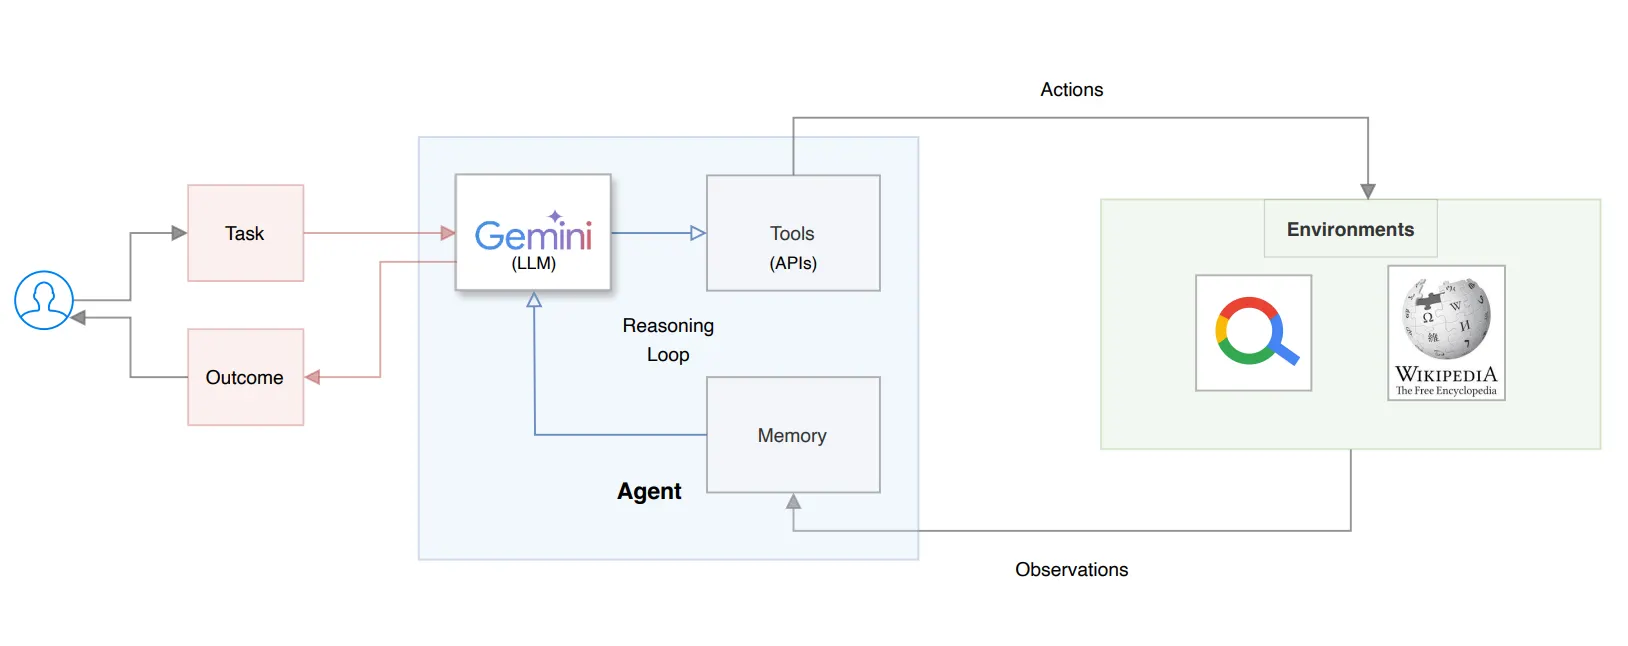

## PART 1: 🧠 Inside the Agent's Mind

Watch how an AI agent **thinks, acts, observes, and remembers**—just like a person!

### **Example 1: Weather Question**

**User Question:** "What's the weather in Paris and should I bring an umbrella?"

**Agent's Tools 🛠️:** 
- `get_weather(city)` - A tool that retrieves weather data

#### The Agent's Thought Loop:

| Step | Part | What the Agent Does |
|------|------|---------------------|
| 1 | 🧠 **Thought** | "I need to answer two things: the weather AND umbrella advice. Let me use my tool to get weather data." |
| 2 | 🛠️ **Action** | Uses tool `get_weather("Paris")` |
| 3 | 👀 **Observation** | Gets the response: `"Paris: 15°C, Rainy"` |
| 4 | 📝 **Memory** | Saves this as a memory: "Paris is 15°C and raining." |
| 5 | 🧠 **Thought** | "Since it's raining, an umbrella is definitely needed. I have all the info for the answer now." |
| 6 | ✅ **Answer** | "It's 15°C and rainy in Paris. Yes, you should bring an umbrella!" |

### **Example 2: Multi-Step Question** (ReAct Cycle)

**User Question:** "What's the capital of Japan and what's 2 + 2?"

**Agent's Tools 🛠️:**
- `get_capital(country)` - A tool that looks up capitals
- `calculate(expression)` - A tool that does math

**Key Insight:** The agent needs to use BOTH tools because there are TWO different questions!

#### The Agent's Thought Loop:

| Step | Part | What the Agent Does |
|------|------|---------------------|
| 1 | 🧠 **Thought** | "I notice this question asks for TWO different things: a capital and a calculation. I'll start with the capital." |
| 2 | 🛠️ **Action** | Uses tool `get_capital("Japan")` |
| 3 | 👀 **Observation** | Gets the response: `"Tokyo"` |
| 4 | 📝 **Memory** | Saves "Japan's capital is Tokyo" to memory. |
| 5 | 🧠 **Thought** | "Now I need to address the second part: the math problem." |
| 6 | 🛠️ **Action** | Uses tool `calculate("2 + 2")` |
| 7 | 👀 **Observation** | Gets the response: `"4"` |
| 8 | 📝 **Memory** | Saves "2 + 2 equals 4" to memory. |
| 9 | 🧠 **Thought** | "I have both pieces of information now. I can combine them for the final answer." |
| 10 | ✅ **Answer** | "The capital of Japan is Tokyo and 2 + 2 is 4!" |

**The ReAct Pattern:**
Notice how we always follow: **Thought → Action → Observation → Memory**. If we aren't done, we start the cycle again with a new **Thought**!

## PART 2: Tools - The Agent's Hands 🙌

Tools are the core capabilities of an AI agent. 

Just like your hands let you interact with the world, **tools let agents interact with data, systems, and the internet.**

In [30]:
def add(a: float, b: float) -> float:
    """Tool #1: Add two numbers."""
    return a + b


def multiply(a: float, b: float) -> float:
    """Tool #2: Multiply two numbers."""
    return a * b


def divide(a: float, b: float) -> float | dict:
    """Tool #3: Divide two numbers. Returns error if b is zero."""
    if b == 0:
        return {"error": "Cannot divide by zero"}
    return a / b


# Test the tools
print("Agent testing its tools:")
print(f"Tool #1 (add): 5 + 3 = {add(5, 3)}")
print(f"Tool #2 (multiply): 4 * 6 = {multiply(4, 6)}")
print(f"Tool #3 (divide): 10 / 2 = {divide(10, 2)}")
print(f"Tool #3 error handling: 10 / 0 = {divide(10, 0)}")

Agent testing its tools:
Tool #1 (add): 5 + 3 = 8
Tool #2 (multiply): 4 * 6 = 24
Tool #3 (divide): 10 / 2 = 5.0
Tool #3 error handling: 10 / 0 = {'error': 'Cannot divide by zero'}


### Exercise 1: Give the Agent a New Tool 🙌

Create a new tool that does something useful. Examples:
- Convert temperature (Celsius to Fahrenheit)
- Calculate area of a rectangle
- Get length of text
- Check if a number is even or odd

Design and test your new tool below:

In [31]:
def my_tool(number):
    """Check if a number is even or odd."""
    if number % 2 == 0:
        return "Even"
    else:
        return "Odd"

# Test your new tool:
print(my_tool(4))  
print(my_tool(7))  

Even
Odd


### Exercise 2: Build More Tools 🔧

Now create **two** more tools:
1. **`subtract(a, b)`** — Subtracts b from a
2. **`power(base, exponent)`** — Raises base to the power of exponent (e.g., 2³ = 8)

Make sure to test them with a few examples!

In [32]:
# TODO: Create a subtract tool
def subtract(a: float, b: float) -> float:
    """Tool: Subtract b from a."""
    return a - b


# TODO: Create a power tool
def power(base: float, exponent: float) -> float:
    """Tool: Raise base to the power of exponent."""
    return base ** exponent


# Test your tools:
print(f"10 - 3 = {subtract(10, 3)}")
print(f"2 ^ 8 = {power(2, 8)}")
print(f"5 ^ 0 = {power(5, 0)}")

10 - 3 = 7
2 ^ 8 = 256
5 ^ 0 = 1


### Exercise 2b: Build a Tool with Error Handling 🛡️

Real-world tools need to handle **bad input** gracefully. An agent shouldn't crash — it should get a helpful error message and try something else.

Create a `safe_divide(a, b)` tool that:
- Returns `{"result": a / b}` when `b` is not zero
- Returns `{"error": "Cannot divide by zero"}` when `b` is zero

**Why does this matter for agents?** If a tool crashes, the entire ReAct loop breaks. Good error handling lets the agent **recover** and try a different approach.

In [33]:
# TODO: Create a safe_divide tool with proper error handling
def safe_divide(a: float, b: float) -> dict:
    """Divide a by b with error handling for division by zero."""
    if b == 0:
        return {"error": "Cannot divide by zero"}
    return {"result": a / b}    
    


# Test cases — all should work without crashing:
print(safe_divide(10, 2))        # Expected: {"result": 5.0}
print(safe_divide(10, 0))        # Expected: {"error": "Cannot divide by zero"}

{'result': 5.0}
{'error': 'Cannot divide by zero'}


## PART 3: Memory - The Agent's Notebook 📝

Now let's see an agent **Reason → Act → Observe → Remember → Repeat**.

### The ReAct Cycle (One Loop):

| Step | Phase | What the Agent Does |
|------|-------|---------------------|
| 1 | 🧠 **Reason** | "What do I need to do? Which hand should I use?" |
| 2 | 🙌 **Act** | Use a tool by calling it with the right input |
| 3 | 👀 **Observe** | Get the result back from the tool |
| 4 | 📝 **Remember** | Store what I learned: "The tool returned X" |
| 5 | 🧠 **Reason Again** | "Do I have what I need, or do I need another tool?" |

If the answer is "I need another tool" → Go back to **Act** (step 2)  
If the answer is "I'm done" → Give the **Final Answer** ✅

In [34]:
# Example: Agent's Thought Process with Memory

# Task: Calculate 25 * 4, then add 10 to the result
task = "Calculate 25 * 4, then add 10 to the result"
print(f"📋 Task: {task}\n")
print("=" * 60)

# --- STEP 1: Multiply 25 * 4 ---
thought = "I need two steps: multiply first, then add. Let me use my multiply tool."
print(f"🧠 Thought: {thought}")

# --- STEP 2: First Action (use multiply tool) ---
result1 = multiply(25, 4)
print("🙌 Action: Use multiply tool → multiply(25, 4)")

# --- STEP 3: First Observation ---
print(f"👀 Observation: Got {result1}")

# --- STEP 4: Memory Update ---
memory = f"Remember: 25 * 4 = {result1}"
print(f"📝 Memory: {memory}\n")


# --- TODO: CONTINUE TO IMPLEMENT THE NEXT STEPS ---
# TODO: Finish the second part of the loop!
# 1. 🧠 Thought: What do you need to do now?
# 2. 🙌 Action: Use the 'add' tool with result1 and 10
# 3. 👀 Observation: What is the result?
# 4. 📝 Memory: Update your final memory
# 5. ✅ Answer: Print the final answer

# YOUR CODE HERE:
thought = "Now I need to add 10 to the previous result. I'll use my add tool."
print(f" Thought: {thought}")

result2 = add(result1, 10)
print(" Action: Use add tool → add(result1, 10)")

print(f" Observation: Got {result2}")

memory = f"Remember: (25 * 4) + 10 = {result2}"
print(f" Memory: {memory}")

print(f" Final Answer: {result2}")



📋 Task: Calculate 25 * 4, then add 10 to the result

🧠 Thought: I need two steps: multiply first, then add. Let me use my multiply tool.
🙌 Action: Use multiply tool → multiply(25, 4)
👀 Observation: Got 100
📝 Memory: Remember: 25 * 4 = 100

 Thought: Now I need to add 10 to the previous result. I'll use my add tool.
 Action: Use add tool → add(result1, 10)
 Observation: Got 110
 Memory: Remember: (25 * 4) + 10 = 110
 Final Answer: 110


### Exercise 3: Complete a 3-Step ReAct Trace 🔄

Now try a **harder** task that requires **three** tool calls!

**Task:** *"Calculate (8 + 2) * 5, then subtract 15 from the result"*

Steps needed:
1. 🙌 Use `add(8, 2)` → get 10
2. 🙌 Use `multiply(result, 5)` → get 50
3. 🙌 Use `subtract(result, 15)` → get 35

Follow the same Thought → Action → Observation → Memory pattern for **all three** steps, then print the final answer.

In [35]:
# Exercise 3: 3-Step ReAct Trace
# Task: Calculate (8 + 2) * 5, then subtract 15 from the result

task = "Calculate (8 + 2) * 5, then subtract 15"
print(f"📋 Task: {task}\n")
print("=" * 60)

# TODO: Complete all 3 steps following the same pattern as the example above
# Each step needs: Thought → Action → Observation → Memory
# Step 1: Add
thought = "First, I need to add 8 and 2. I'll use my add tool."
print(f" Thought: {thought}")
result1 = add(8, 2)
print(" Action: Use add tool → add(8, 2)")
print(f" Observation: Got {result1}")
memory = f"Remember: 8 + 2 = {result1}"
print(f" Memory: {memory}\n")
print("=" * 60)
# Step 2: Multiply
thought = "Now I need to multiply the previous result by 5. I'll use my multiply tool."
print(f" Thought: {thought}")
result2 = multiply(result1, 5)
print(" Action: Use multiply tool → multiply(result1, 5)")
print(f" Observation: Got {result2}")
memory = f"Remember: (8 + 2) * 5 = {result2}"
print(f" Memory: {memory}\n")
print("=" * 60)
# Step 3: Subtract
thought = "Finally, I need to subtract 15 from the previous result. I'll use my subtract tool."
print(f" Thought: {thought}")
result3 = subtract(result2, 15)
print(" Action: Use subtract tool → subtract(result2, 15)")
print(f" Observation: Got {result3}")
memory = f"Remember: ((8 + 2) * 5) - 15 = {result3}"
print(f" Memory: {memory}\n")
print("=" * 60)
# Then print the final answer
print(f" Final Answer: {result3}")

📋 Task: Calculate (8 + 2) * 5, then subtract 15

 Thought: First, I need to add 8 and 2. I'll use my add tool.
 Action: Use add tool → add(8, 2)
 Observation: Got 10
 Memory: Remember: 8 + 2 = 10

 Thought: Now I need to multiply the previous result by 5. I'll use my multiply tool.
 Action: Use multiply tool → multiply(result1, 5)
 Observation: Got 50
 Memory: Remember: (8 + 2) * 5 = 50

 Thought: Finally, I need to subtract 15 from the previous result. I'll use my subtract tool.
 Action: Use subtract tool → subtract(result2, 15)
 Observation: Got 35
 Memory: Remember: ((8 + 2) * 5) - 15 = 35

 Final Answer: 35


---

## PART 4: 🧠 From Manual to AI Brain - Using Real LLMs with OpenAI API

So far, we've **manually** written what the agent thinks. But real agents have an **AI brain** that reasons automatically!

Instead of us writing the reasoning, we use **OpenAI's GPT-4 model** via the **OpenAI API** to generate thoughts.

### The Complete Loop:

**Task → [ Reason → Act → Observe → Remember ]* → Answer**

At each iteration:
1. **🧠 Reason**: GPT-4 thinks about the task and what to do next
2. **🙌 Act**: Execute the tools GPT-4 requests
3. **👀 Observe**: Get the results back
4. **📝 Remember**: Add results to memory (conversation)
5. **🧠 Reason (again)**: Decide: Continue loop? Or give final answer?

The loop **automatically stops** when:
- ✅ GPT-4 returns a final answer (not a tool call)
- ⚠️ Max iterations reached (safety limit)

Let's build it!

# Step 1: Setup OpenAI Client


In [36]:
from openai import OpenAI
import os
from dotenv import load_dotenv
import json

# Load environment variables from .env file
load_dotenv()

openai_endpoint = os.getenv("OPENAI_ENDPOINT")
openai_api_key = os.getenv('OPENAI_API_KEY' )

MODEL = "gpt-4.1-mini"

if not openai_endpoint or not openai_api_key:
    raise ValueError("❌ OpenAI credentials not found!\n")

client = OpenAI(
    base_url=openai_endpoint,
    api_key=openai_api_key,
)

print(f"✅ OpenAI configured (model: {MODEL}")
#print(f"✅ OpenAI configured (openai_endpoint: {openai_endpoint}")
#print(f"✅ OpenAI configured (openai_api_key: {openai_api_key}")


✅ OpenAI configured (model: gpt-4.1-mini


# Step 2: Define the Agent's Tools

### Define tool functions

In [37]:
def add_numbers(a: float, b: float) -> dict:
    """Add two numbers."""
    return {"result": a + b}


def multiply_numbers(a: float, b: float) -> dict:
    """Multiply two numbers."""
    return {"result": a * b}


def divide_numbers(a: float, b: float) -> dict:
    """Divide two numbers (handles division by zero)."""
    if b == 0:
        return {"error": "Cannot divide by zero"}
    return {"result": a / b}


def final_answer(answer: str, explanation: str = ""):
    """Returns the final answer to the user."""
    return answer


# Tools the agent is allowed to call
tools = [add_numbers, multiply_numbers, divide_numbers, final_answer]

#### Create function declarations that will let the agent know what tools it can use.

In [38]:
# Tool name -> Python function mapping
TOOLS_MAP = {
    "add_numbers": add_numbers,
    "multiply_numbers": multiply_numbers,
    "divide_numbers": divide_numbers,
    # "final_answer" is handled specially inside react_cycle()
}

print("✅ Agent Tools Defined:")
for name in TOOLS_MAP.keys():
    print(f"   🙌 {name}")

✅ Agent Tools Defined:
   🙌 add_numbers
   🙌 multiply_numbers
   🙌 divide_numbers


# Step 3: The ReAct Cycle

## How It Works:

1. **Send user prompt + tools to GPT-4.1**: "Here's a task and here are the tools you can use"
2. **Loop**  until final answer is provided or max_iterations is reached:
   - 🧠 GPT-4.1 thinks and decides: "Do I need a tool, or can I answer?"
   - If tool needed:
     - 🙌 GPT-4.1 tells us which tool and what arguments
     - 👀 We call the tool and get result
     - 📝 We add result to memory and send back to GPT-4.1
   - If answer ready:
     - ✅ Return the final answer and stop loop

## The Code:

#### Helper functions for tidy code.

In [39]:
import inspect
from typing import Callable, get_type_hints


def function_to_openai_tool(func: Callable) -> dict:
    """Convert a Python function to Responses API tool format."""

    sig = inspect.signature(func)
    hints = get_type_hints(func) if hasattr(func, "__annotations__") else {}

    properties = {}
    required = []

    for param_name, param in sig.parameters.items():
        param_type = hints.get(param_name, str)

        json_type = "string"
        if param_type in (int, float):
            json_type = "number"
        elif param_type is bool:
            json_type = "boolean"

        properties[param_name] = {"type": json_type}
        if param.default == inspect.Parameter.empty:
            required.append(param_name)

    return {
        "type": "function",
        "name": func.__name__,
        "description": func.__doc__ or "",
        "parameters": {
            "type": "object",
            "properties": properties,
            "required": required,
        },
    }

In [40]:
def get_response(
    input_items: list,
    tools: list,
    previous_response_id: str | None = None,
    instructions: str | None = None,
):
    """Call the OpenAI Responses API with tool support."""

    openai_tools = [function_to_openai_tool(t) for t in tools]
    return client.responses.create(
        model=MODEL,
        input=input_items,
        tools=openai_tools,
        tool_choice="auto",
        previous_response_id=previous_response_id,
        instructions=instructions,
    )

In [41]:
def execute_tool(tool_name: str, tool_args: dict, tool_map: dict):
    """Run a tool and return its result (or an error dict)."""

    if tool_name not in tool_map:
        return {"error": f"Tool '{tool_name}' not found"}

    try:
        return tool_map[tool_name](**(tool_args or {}))
    except Exception as exc:
        return {"error": str(exc)}

In [42]:
def extract_function_calls(response) -> list:
    """Return function_call items from a Responses API response."""

    return [
        item
        for item in (response.output or [])
        if getattr(item, "type", None) == "function_call"
    ]

#### ReAct Cycle function

In [43]:
DEFAULT_SYSTEM_INSTRUCTION = "Solve this task. You must use tools to help you."

 
def format_final_answer(tool_args: dict) -> str:
    """Format the final answer payload the model returns via the final_answer tool."""
    answer = tool_args.get("answer")
    explanation = tool_args.get("explanation")

    if explanation:
        # Make explanations easier to read by adding line breaks after sentences.
        explanation = explanation.replace(". ", ".\n")
        return f"{answer}\n\n📝 Explanation:\n{explanation}"

    return answer


def react_cycle(
    task: str,
    tools: list,
    tool_map: dict,
    system_instruction: str = DEFAULT_SYSTEM_INSTRUCTION,
    max_iterations: int = 10,
) -> str | None:
    """Run a simple ReAct loop: reason -> act -> observe -> repeat."""

    # We explicitly tell the model how to stop:
    # when it's done, it should call the `final_answer` tool.
    instructions = (
        f"{system_instruction} When you have the answer, use the final_answer tool."
    )

    # The Responses API can keep a server-side conversation thread.
    # We pass `previous_response_id` so each iteration continues the same conversation.
    previous_response_id = None

    # `messages` is what we send to the model each iteration.
    # First time: we send the user task.
    messages = [{"role": "user", "content": f"Task: {task}"}]

    for iteration in range(max_iterations):
        print(f"\n--- ITERATION {iteration + 1} ---")

        # 1) REASON: ask the model what to do next (and allow tool calling)
        try:
            response = get_response(
                messages,
                tools,
                previous_response_id=previous_response_id,
                instructions=instructions,
            )
            print("🧠 REASON")
        except Exception as exc:
            print(f"⚠️ Error during generation: {exc}")
            return None

        # Save response id so the next call continues the same thread.
        previous_response_id = response.id

        # 2) Check whether the model asked to call any tools.
        tool_calls = extract_function_calls(response)

        # If there are no tool calls, we expect the model to just answer normally.
        if not tool_calls:
            text = getattr(response, "output_text", None)
            if text:
                print(f"✅ FINAL ANSWER: {text}")
                return text

            print("⚠️ Model returned empty response (no text, no tools).")
            return None

        # 3) ACT + OBSERVE: run each requested tool and capture its output.
        tool_outputs = []
        for call in tool_calls:
            tool_name = call.name

            # Tool arguments arrive as JSON; parse them into a Python dict.
            tool_args = (
                json.loads(call.arguments) if getattr(call, "arguments", None) else {}
            )

            print(f"🙌 ACT: Calling '{tool_name}' with {tool_args}")

            # Special case: the model is done and wants to return a final answer.
            if tool_name == "final_answer":
                final_text = format_final_answer(tool_args)
                print(f"✅ FINAL ANSWER: {final_text}")
                return final_text

            # Normal tools (like add_numbers/multiply_numbers/divide_numbers)
            result = execute_tool(tool_name, tool_args, tool_map)
            print(f"👀 OBSERVE: Result = {result}")

            # 4) REMEMBER: store tool result in the exact format the Responses API expects,
            # so we can send it back to the model on the next iteration.
            tool_outputs.append(
                {
                    "type": "function_call_output",
                    "call_id": call.call_id,
                    "output": json.dumps(result),
                }
            )
            print(f"📝 REMEMBER: Stored result for '{tool_name}'")

        # Next iteration: we send ONLY the tool outputs.
        # The model will still know the task because we continue the same thread
        # using `previous_response_id`.
        messages = tool_outputs

    print(f"⚠️ Max iterations ({max_iterations}) reached")
    return None


# Test the ReAct cycle with a sample task
result = react_cycle(
    "Calculate (100 + 50) * 2, then divide the result by 3",
    tools,
    TOOLS_MAP,
)



--- ITERATION 1 ---
🧠 REASON
🙌 ACT: Calling 'add_numbers' with {'a': 100, 'b': 50}
👀 OBSERVE: Result = {'result': 150}
📝 REMEMBER: Stored result for 'add_numbers'
🙌 ACT: Calling 'divide_numbers' with {'a': 0, 'b': 3}
👀 OBSERVE: Result = {'result': 0.0}
📝 REMEMBER: Stored result for 'divide_numbers'

--- ITERATION 2 ---
🧠 REASON
🙌 ACT: Calling 'multiply_numbers' with {'a': 150, 'b': 2}
👀 OBSERVE: Result = {'result': 300}
📝 REMEMBER: Stored result for 'multiply_numbers'

--- ITERATION 3 ---
🧠 REASON
🙌 ACT: Calling 'divide_numbers' with {'a': 300, 'b': 3}
👀 OBSERVE: Result = {'result': 100.0}
📝 REMEMBER: Stored result for 'divide_numbers'

--- ITERATION 4 ---
🧠 REASON
🙌 ACT: Calling 'final_answer' with {'answer': '100', 'explanation': 'First, we added 100 and 50 to get 150. Then, we multiplied 150 by 2 to get 300. Finally, we divided 300 by 3 to get the final result of 100.'}
✅ FINAL ANSWER: 100

📝 Explanation:
First, we added 100 and 50 to get 150.
Then, we multiplied 150 by 2 to get 30

### Exercise 4: Test the Agent with Your Own Task 🤖

The `react_cycle` function is your AI agent! Try giving it a **different math problem** and watch the ReAct loop in action.

Ideas to try:
- `"What is 999 divided by 3, then add 7?"`
- `"Multiply 12 by 8, then divide by 4"`  
- `"Add 100 and 250, then multiply by 0"`

In [44]:
# TODO: Write your own task and run the react_cycle!
my_task = "subtract 550 from 2000, then multiply by 1?"
my_result = react_cycle(my_task, tools, TOOLS_MAP)
print(f"\n🎯 Agent's answer: {my_result}")


--- ITERATION 1 ---
🧠 REASON
🙌 ACT: Calling 'add_numbers' with {'a': 2000, 'b': -550}
👀 OBSERVE: Result = {'result': 1450}
📝 REMEMBER: Stored result for 'add_numbers'

--- ITERATION 2 ---
🧠 REASON
🙌 ACT: Calling 'multiply_numbers' with {'a': 1450, 'b': 1}
👀 OBSERVE: Result = {'result': 1450}
📝 REMEMBER: Stored result for 'multiply_numbers'

--- ITERATION 3 ---
🧠 REASON
🙌 ACT: Calling 'final_answer' with {'answer': '1450', 'explanation': 'First, subtracting 550 from 2000 gives 1450. Then multiplying 1450 by 1 results in 1450.'}
✅ FINAL ANSWER: 1450

📝 Explanation:
First, subtracting 550 from 2000 gives 1450.
Then multiplying 1450 by 1 results in 1450.

🎯 Agent's answer: 1450

📝 Explanation:
First, subtracting 550 from 2000 gives 1450.
Then multiplying 1450 by 1 results in 1450.


### Exercise 4b: Expand the Agent's Toolbox 🧰

The LLM-powered agent currently only has `add_numbers`, `multiply_numbers`, and `divide_numbers`. But it can't subtract!

**Task:**
1. Create a new `subtract_numbers(a, b)` function (same style as the others — typed parameters, returns a dict)
2. Add it to the `tools` list AND the `TOOLS_MAP`
3. Test the agent with a task that **requires subtraction**, like: `"What is 500 minus 137, then multiply by 2?"`


In [45]:
# TODO: Create a subtract_numbers tool (same style as add_numbers)
def subtract_numbers(a: float, b: float) -> dict:
    """Subtract b from a."""
    return {"result": a - b}

# TODO: Add it to the tools list and TOOLS_MAP
tools = [add_numbers, multiply_numbers, divide_numbers, subtract_numbers, final_answer]
TOOLS_MAP = {
    "add_numbers": add_numbers,
    "multiply_numbers": multiply_numbers,
    "divide_numbers": divide_numbers,
    "subtract_numbers": subtract_numbers,
    # "final_answer" is handled specially inside react_cycle()
}

# TODO: Test the agent with a subtraction task
my_task = "What is 742 plus 317, then multiply by 2?"
my_result = react_cycle(my_task, tools, TOOLS_MAP)
print(f"\n Agent's answer: {my_result}")


--- ITERATION 1 ---
🧠 REASON
🙌 ACT: Calling 'add_numbers' with {'a': 742, 'b': 317}
👀 OBSERVE: Result = {'result': 1059}
📝 REMEMBER: Stored result for 'add_numbers'
🙌 ACT: Calling 'multiply_numbers' with {'a': 317, 'b': 2}
👀 OBSERVE: Result = {'result': 634}
📝 REMEMBER: Stored result for 'multiply_numbers'

--- ITERATION 2 ---
🧠 REASON
🙌 ACT: Calling 'multiply_numbers' with {'a': 1059, 'b': 2}
👀 OBSERVE: Result = {'result': 2118}
📝 REMEMBER: Stored result for 'multiply_numbers'

--- ITERATION 3 ---
🧠 REASON
🙌 ACT: Calling 'final_answer' with {'answer': '2118', 'explanation': 'First, 742 plus 317 equals 1059. Then, multiplying 1059 by 2 gives 2118.'}
✅ FINAL ANSWER: 2118

📝 Explanation:
First, 742 plus 317 equals 1059.
Then, multiplying 1059 by 2 gives 2118.

 Agent's answer: 2118

📝 Explanation:
First, 742 plus 317 equals 1059.
Then, multiplying 1059 by 2 gives 2118.


### Exercise 4c: Change the Agent's Personality 🎭

The `system_instruction` parameter controls **how** the agent behaves — its personality, style, and rules.

**Task:** Run the **same math task** with two different system instructions and compare the results:
1. `"You are a precise math teacher. Show your work step by step."`
2. `"You are a pirate. Answer like a pirate but still use tools for calculations."`

**What to observe:** How does the system instruction change the agent's behavior? Does it affect tool usage or just the final answer text?

In [46]:
# TODO: Try the same task with two different system instructions (see descriptions above)
task = "Calculate 15 + 27, then multiply by 3"

# TODO Instruction 1: Precise math teacher
system_instruction_1 = "You are a precise math teacher. Show your work step by step."
result_1 = react_cycle(task, tools, TOOLS_MAP, system_instruction=system_instruction_1)
print("\nMath Teacher's answer:")
print(result_1)

# TODO Instruction 2: Pirate
system_instruction_2 = "You are a pirate. Answer like a pirate but still use tools for calculations."
result_2 = react_cycle(task, tools, TOOLS_MAP, system_instruction=system_instruction_2)
print("\nPirate's answer:")
print(result_2)


--- ITERATION 1 ---
🧠 REASON
🙌 ACT: Calling 'add_numbers' with {'a': 15, 'b': 27}
👀 OBSERVE: Result = {'result': 42}
📝 REMEMBER: Stored result for 'add_numbers'

--- ITERATION 2 ---
🧠 REASON
🙌 ACT: Calling 'multiply_numbers' with {'a': 42, 'b': 3}
👀 OBSERVE: Result = {'result': 126}
📝 REMEMBER: Stored result for 'multiply_numbers'

--- ITERATION 3 ---
🧠 REASON
🙌 ACT: Calling 'final_answer' with {'answer': '126', 'explanation': 'First, add 15 and 27 to get 42. Then multiply 42 by 3 to get 126.'}
✅ FINAL ANSWER: 126

📝 Explanation:
First, add 15 and 27 to get 42.
Then multiply 42 by 3 to get 126.

Math Teacher's answer:
126

📝 Explanation:
First, add 15 and 27 to get 42.
Then multiply 42 by 3 to get 126.

--- ITERATION 1 ---
🧠 REASON
🙌 ACT: Calling 'add_numbers' with {'a': 15, 'b': 27}
👀 OBSERVE: Result = {'result': 42}
📝 REMEMBER: Stored result for 'add_numbers'
🙌 ACT: Calling 'multiply_numbers' with {'a': 42, 'b': 3}
👀 OBSERVE: Result = {'result': 126}
📝 REMEMBER: Stored result for 'm

### Exercise 4d: Test Edge Cases & Safety Limits ⚠️

Agents can get **stuck in loops** or take too many steps. The `max_iterations` parameter is a safety net.

**Task 1:** Run a complex multi-step task with `max_iterations=1`. What happens?

**Task 2:** Ask the agent to divide by zero: `"What is 10 divided by 0?"`. How does the agent handle the error from the tool?

**Key Insight:** These edge cases show why agents need good error handling, iteration limits, and clear tool descriptions!

In [47]:
# TODO Task 1: Test with max_iterations=1 on a multi-step problem
# What happens when the agent doesn't have enough iterations?
task = "Add 10 and 20, then multiply by 5, then divide by 2"
result = react_cycle(
    task,
    tools,
    TOOLS_MAP,
    max_iterations=1
)
print("\nAgent's answer with max_iterations=1:")
print(result)


--- ITERATION 1 ---
🧠 REASON
🙌 ACT: Calling 'add_numbers' with {'a': 10, 'b': 20}
👀 OBSERVE: Result = {'result': 30}
📝 REMEMBER: Stored result for 'add_numbers'
⚠️ Max iterations (1) reached

Agent's answer with max_iterations=1:
None


In [48]:
# TODO Task 2: Test division by zero — how does the agent handle tool errors?
task = "What is 10 divided by 0?"
result = react_cycle(
    task,
    tools,
    TOOLS_MAP
)
print("\nAgent's answer for division by zero:")
print(result)


--- ITERATION 1 ---
🧠 REASON
🙌 ACT: Calling 'divide_numbers' with {'a': 10, 'b': 0}
👀 OBSERVE: Result = {'error': 'Cannot divide by zero'}
📝 REMEMBER: Stored result for 'divide_numbers'

--- ITERATION 2 ---
🧠 REASON
🙌 ACT: Calling 'final_answer' with {'answer': 'Undefined', 'explanation': '10 divided by 0 is undefined because division by zero is not possible in mathematics.'}
✅ FINAL ANSWER: Undefined

📝 Explanation:
10 divided by 0 is undefined because division by zero is not possible in mathematics.

Agent's answer for division by zero:
Undefined

📝 Explanation:
10 divided by 0 is undefined because division by zero is not possible in mathematics.


## PART 5: 🚀 Challenge: Build a Web Search Agent!

Now it's time to give your agent **super-vision**! 

Your agent is smart, but it doesn't know about current events (like today's news). We'll fix that by giving it a "Web Search" hand using **Tavily**, a search engine built specifically for AI agents.

### 1. Get your Tavily API key 🔑 (5 minutes)
1. Create a free account at [tavily.com](https://tavily.com).

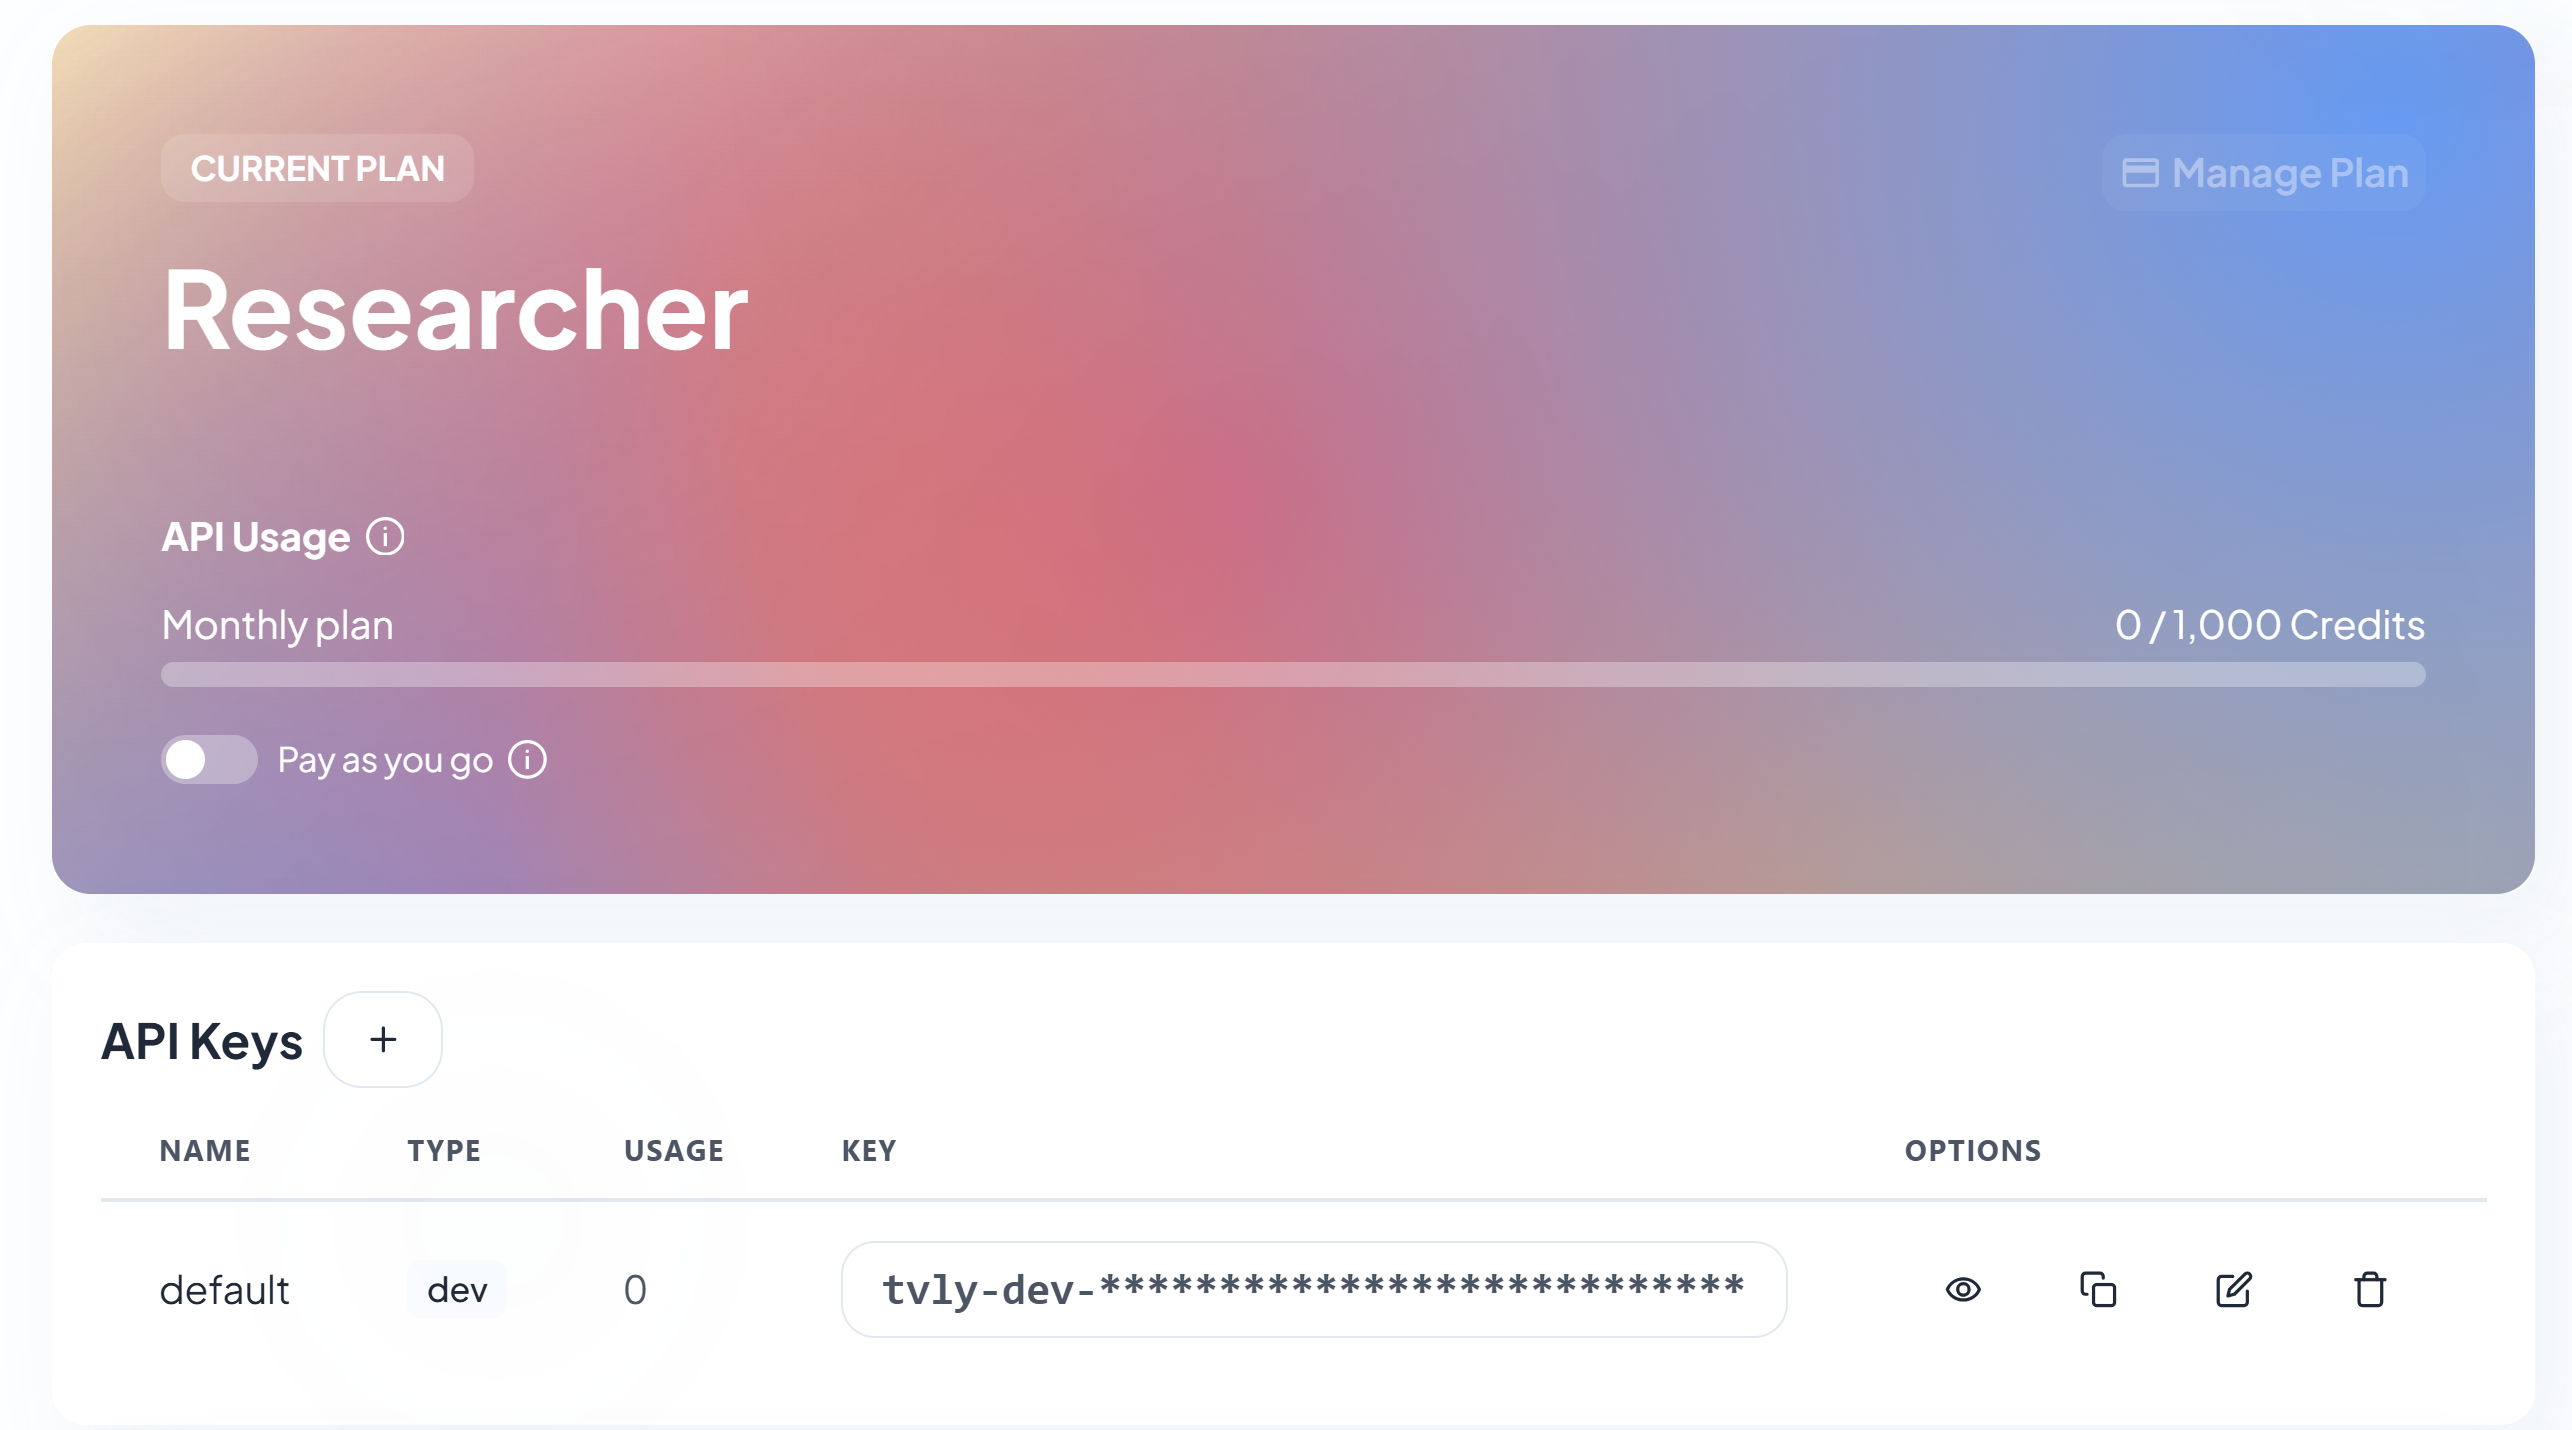

2. Copy the default API key.
3. Add it to your `.env` file: `TAVILY_API_KEY=tvly-...`


### 2. The Mission 🕵️‍♂️
Build an agent that can answer:
> **"What is the weather today in Latvia and Lithuania?"**

### 3. Your Toolkit 🧰
You'll need to:
1.  Create a `search_web(query)` function using Tavily.
2.  Add it to your `tools` list.
3.  Update the `TOOLS_MAP`.
4.  Run the `react_cycle` with a question that needs searching!


In [49]:
from tavily import TavilyClient

# 1. Setup Tavily
tavily_api_key = os.getenv("TAVILY_API_KEY")
if not tavily_api_key:
    raise ValueError(
        "❌ TAVILY_API_KEY not found!\n"
        "   Make sure your .env file contains: TAVILY_API_KEY=your-api-key\n"
    )

tavily_client = TavilyClient(api_key=tavily_api_key)


# 2. CREATE YOUR SEARCH TOOL
def search_web(query: str) -> dict:
    """
    Searches the web for the given query.
    Useful for getting up-to-date information, news, or facts.
    """
    # TODO: Use tavily_client.search() to get results and return them as a dict
    # Hint: Look at the tavily_client.search() method and its max_results parameter
    result = tavily_client.search(query=query, max_results=3)
    return {"result": result}


# 3. UPDATE YOUR TOOL LISTS
# TODO: Add your new search_web tool and final_answer to the tools list for OpenAI
my_new_tools = [search_web, final_answer]

# TODO: Add the tool mapping (string name to function)
# Note: "final_answer" is handled specially inside react_cycle(), so don't add it here!
MY_TOOLS_MAP = {
    "search_web": search_web,
}

In [50]:
# 4. USE IT
# Ask a question that requires searching the web
question = (
    "What is the current stock price of Tesla? And what is 10 shares of it worth?"
)

# Run the cycle!
# Now we explicitely pass our tools and a custom system prompt
system_prompt = (
    "You are a helpful assistant with access to the web. "
    "Use the search_web tool to find real-time information."
)

answer = react_cycle(
    question,
    tools=my_new_tools,
    tool_map=MY_TOOLS_MAP,
    system_instruction=system_prompt,
)


--- ITERATION 1 ---
🧠 REASON
🙌 ACT: Calling 'search_web' with {'query': 'Tesla current stock price'}
👀 OBSERVE: Result = {'result': {'query': 'Tesla current stock price', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.tradingview.com/symbols/NASDAQ-TSLA/', 'title': 'TSLA Stock Price - Tesla, Inc. - TradingView', 'content': 'The current price of TSLA is 409.38 USD — it has increased by 2.45% in the past 24 hours. Watch Tesla, Inc. stock price performance more closely on the chart.', 'score': 0.92794675, 'raw_content': None}, {'url': 'https://robinhood.com/us/en/stocks/TSLA/', 'title': 'Tesla: TSLA Stock Price Quote & News', 'content': 'At a current price of $411.26, the stock is +0.7% higher than the low and still -2.2% under the high. Trading volume for Tesla(TSLA) stock has reached 8.63M,', 'score': 0.90849644, 'raw_content': None}, {'url': 'https://www.etoro.com/markets/tsla', 'title': 'TSLA Stock Price | Analyst Target 421.00 & Moderate 

### Exercise 5: Ask a Multi-Step Web + Math Question 🌐🧮

Now ask your agent a question that requires **both** web search **and** math!

The agent should:
1. Search the web for some information
2. Use that information in a calculation

Example questions:
- `"What is the population of Lithuania? Divide it by 1000."`
- `"Search for the height of the Eiffel Tower in meters, then multiply it by 3."`
- `"What is the weather in Latvia? If the temperature is above 20, add 5, otherwise subtract 5."`

In [51]:
# TODO: Ask a question that needs BOTH web search and math
# Use react_cycle with your tools and an appropriate system instruction
question = "Find the length of the Golden Gate Bridge in meters, then subtract 500 from it."
system_prompt = (
    "You are a helpful assistant with access to the web and math tools. "
    "First, search for the length of the Golden Gate Bridge in meters, then subtract 500 from the result."
)

answer = react_cycle(
    question,
    tools=my_new_tools,
    tool_map=MY_TOOLS_MAP,
    system_instruction=system_prompt,
)
print(answer)


--- ITERATION 1 ---
🧠 REASON
🙌 ACT: Calling 'search_web' with {'query': 'length of the Golden Gate Bridge in meters'}
👀 OBSERVE: Result = {'result': {'query': 'length of the Golden Gate Bridge in meters', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.facebook.com/groups/SanFranciscoPhotography/posts/2542319092579382/', 'title': 'What are the dimensions of the Golden Gate Bridge? - Facebook', 'content': "The Golden Gate Bridge has the world's fourth tallest pylon, 227.4 meters high, and the total length of the bridge is 2737.4 meters.", 'score': 0.9998568, 'raw_content': None}, {'url': 'https://www.bridgeinfo.net/bridge/index.php?ID=91', 'title': 'Golden Gate Bridge - Bridgeinfo.net', 'content': '# Golden Gate Bridge. Golden Gate Bridge is one of the worlds most famous bridges, the suspension bridge connects San Francisco with Marin County in California in America. Construction of the bridge started in 1933 and in 1937 the bridge was finish

### 🏆 Final - Exercise 6: Build a Multi-Topic Research Agent

This is the **ultimate challenge!** Build an agent that can research multiple topics and compare them.

**Task:** Ask your agent a question that requires **multiple web searches** and **combining** the results:

> *"Compare the populations of Latvia and Lithuania. Which country has more people and by how many?"*

The agent will need to:
1. Search for Latvia's population
2. Search for Lithuania's population
3. Use `subtract_numbers` to find the difference
4. Give a final comparison

**Hints:**
- Make sure `subtract_numbers` and `search_web` are both in your tools list and map
- Use a good system instruction that tells the agent to search for each country separately
- Set `max_iterations` high enough (e.g., 10) since multiple searches take multiple iterations

In [52]:
# TODO: Build a tools list and map that includes search_web AND subtract_numbers (plus the other math tools)

# - search_web(query: str) -> dict
# - subtract_numbers(a: float, b: float) -> dict
# - add_numbers(a: float, b: float) -> dict
# - multiply_numbers(a: float, b: float) -> dict
# - divide_numbers(a: float, b: float) -> dict
# - final_answer(answer: str, explanation: str = "") -> str

my_tools = [
    search_web,
    subtract_numbers,
    add_numbers,
    multiply_numbers,
    divide_numbers,
    final_answer
]

MY_TOOLS_MAP = {
    "search_web": search_web,
    "subtract_numbers": subtract_numbers,
    "add_numbers": add_numbers,
    "multiply_numbers": multiply_numbers,
    "divide_numbers": divide_numbers,
    # "final_answer" is handled specially inside react_cycle()
}

my_question = "Compare the populations of Latvia and Lithuania. Which country has more people and by how many?"
my_system_instruction = (
    "You are a helpful research agent. For each country, search for its population separately, "
    "then use subtract_numbers to find the difference. Explain your reasoning step by step."
)

my_result = react_cycle(
    my_question,
    tools=my_tools,
    tool_map=MY_TOOLS_MAP,
    system_instruction=my_system_instruction,
    max_iterations=10
)
print(f"\nAgent's answer: {my_result}")


--- ITERATION 1 ---
🧠 REASON
🙌 ACT: Calling 'search_web' with {'query': 'population of Latvia'}
👀 OBSERVE: Result = {'result': {'query': 'population of Latvia', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://stat.gov.lv/en/statistics-themes/population/population/press-releases/22900-number-population-latvia-2024', 'title': 'Latvia has a population of almost 1.86 million', 'content': 'In 2024, 63.0\xa0% of the total population were of working age (15–64\xa0years), and the share has reduced by 0.1\xa0% compared to 2023. **Compared to 2024, population of Latvia has declined by 1.0\xa0%, or by 18.4 thousand\xa0people.** As a result of negative natural change, with deaths outnumbering births, the total population declined by 0.7\xa0%, or 13.8\xa0thousand people. The greatest proportion of children and adolescents (0–14\xa0years) in the total population of the respective region was registered in Riga region \xad– 15.7\xa0%. Last year, Latvia had urba

# Final Note:
- You have learned how AI Agents work under the hood which is the foundation of Agentic AI!

- Next you will learn frameworks that make building agents and their workflows easier, like LangChain and LangGraph.

- Have fun coding! 🚀